
# Seasonal Agriculture Performance Analysis

## Major Project – VOIS AICTE Batch 1 2026–2027



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#import the data set
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.shape

(4000, 28)

In [6]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## Data Cleaning


In [9]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [10]:
df.isnull().sum().sum()

np.int64(120)

#duplicates


In [15]:
dup_count = df.duplicated().sum()
print("Duplicate rows are",dup_count)
df[df.duplicated()]

Duplicate rows are 0


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct


In [25]:
missing = pd.DataFrame({
    'Missing Count':df.isna().sum(),
    'Missing %':(df.isna().mean()*100).round(2)
})
missing = missing[missing['Missing Count']>0]
missing.sort_values('Missing Count',ascending=False)

,Missing Count,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [26]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [27]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [28]:
# Check the different seasons

print("Seasons:")
print(df["Season"].unique())

Seasons:
['Kharif' 'Rabi' 'Zaid']


In [29]:
# Check the different crops

print("Crops:")
print(df["Crop"].unique())

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']


In [30]:
# Check irrigation methods

print("Irrigation Methods:")
print(df["Irrigation_Method"].unique())

Irrigation Methods:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [32]:
# Categorical columns: missing means the category is not available.

categorical_columns = df.select_dtypes(include='object').columns.tolist()

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

In [33]:
# Rows without yield are removed from the analysis.

df = df.dropna(subset=['Yield_Tonnes_Ha']).copy()

print("Dataset shape after handling missing yield:", df.shape)

Dataset shape after handling missing yield: (3968, 28)


In [34]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

# Fill missing numerical values

for col in numerical_columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [35]:
missing_after = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing_after = missing_after[missing_after['Missing Count'] > 0]

missing_after.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3968 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        3968 non-null   object 
 1   State                          3968 non-null   object 
 2   District                       3968 non-null   object 
 3   Crop                           3968 non-null   object 
 4   Season                         3968 non-null   object 
 5   Farm_Area_Hectares             3968 non-null   float64
 6   Rainfall_mm                    3968 non-null   float64
 7   Avg_Temperature_C              3968 non-null   float64
 8   Humidity_pct                   3968 non-null   float64
 9   Sunlight_Hours_Day             3968 non-null   float64
 10  Soil_pH                        3968 non-null   float64
 11  Soil_Moisture_pct              3968 non-null   float64
 12  Nitrogen_kg_ha                 3968 non-null   float6

Exploratory Data Analysis

In [37]:
season_counts = df["Season"].value_counts()

season_counts

,count
Season,
Kharif,1772
Rabi,1607
Zaid,589


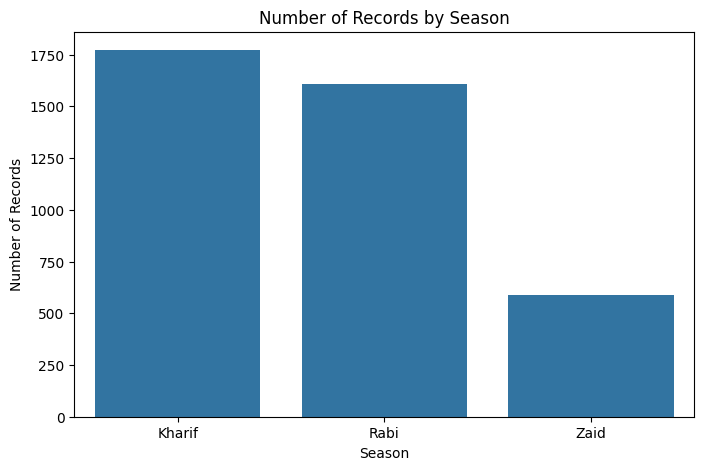

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Season")

plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.show()

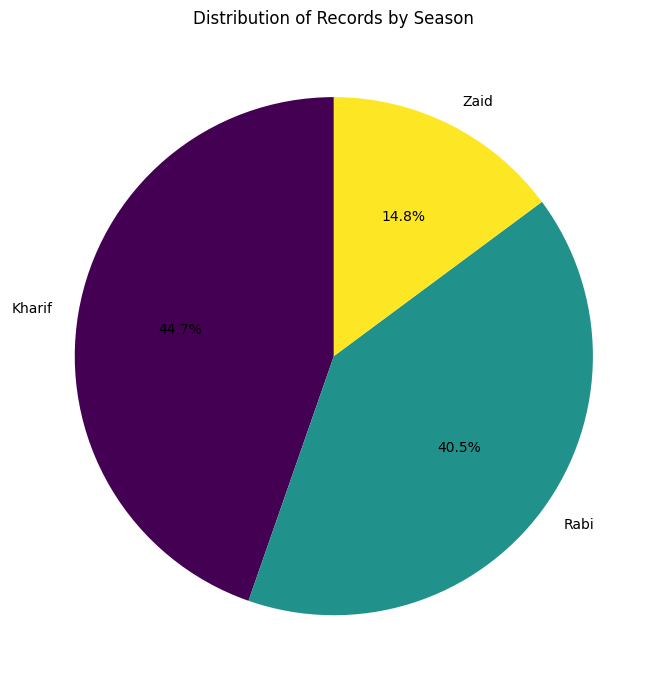

In [92]:
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()



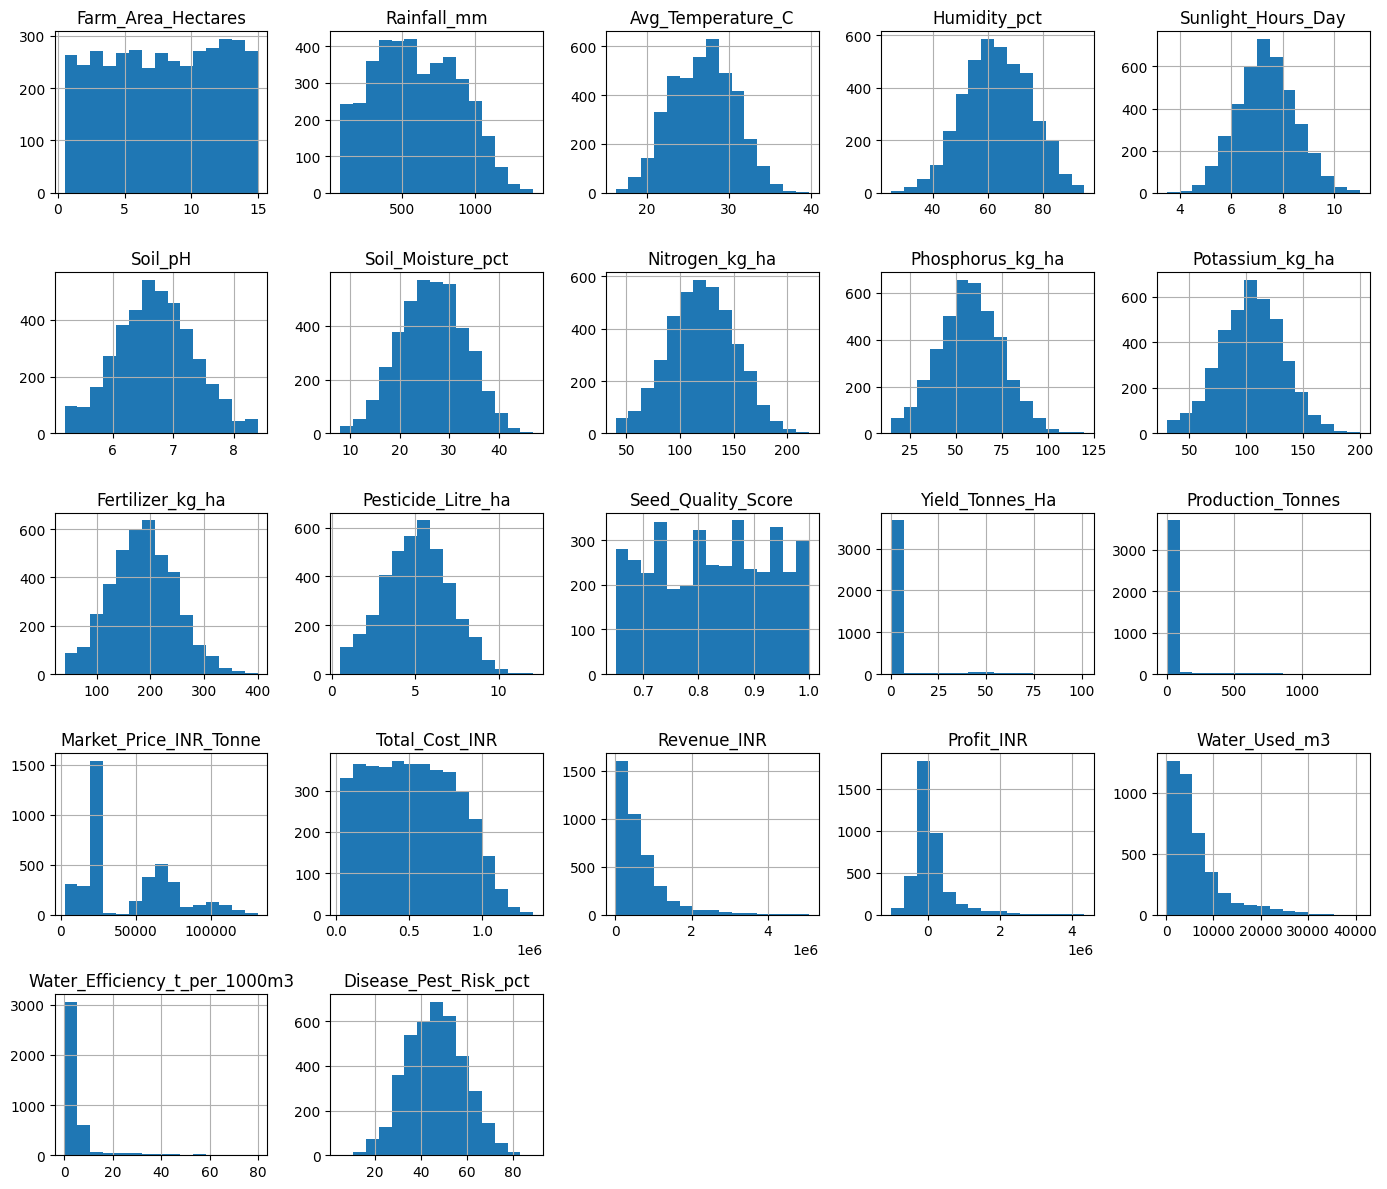

In [39]:
df.hist(bins=15, figsize=(14, 12))

plt.tight_layout()
plt.show()

In [40]:
def find_outlier_limits(column):
    Q1, Q3 = column.quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower_range = Q1 - (1.5 * IQR)
    upper_range = Q3 + (1.5 * IQR)

    return lower_range, upper_range

In [41]:
outlier_summary = []

for col in numerical_columns:
    low, high = find_outlier_limits(df[col])

    outlier_count = ((df[col] < low) | (df[col] > high)).sum()

    outlier_summary.append([
        col,
        round(low, 2),
        round(high, 2),
        int(outlier_count)
    ])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Lower Limit", "Upper Limit", "Outlier Count"]
)

outlier_summary.sort_values("Outlier Count", ascending=False)

,Column,Lower Limit,Upper Limit,Outlier Count
18,Profit_INR,-697449.75,764370.25,398
14,Production_Tonnes,-23.97,53.39,329
20,Water_Efficiency_t_per_1000m3,-3.57,10.39,319
13,Yield_Tonnes_Ha,-1.63,5.52,302
19,Water_Used_m3,-6084.88,16176.12,273
17,Revenue_INR,-729514.00,1773516.00,240
9,Potassium_kg_ha,30.19,179.49,33
4,Sunlight_Hours_Day,4.35,10.35,26
8,Phosphorus_kg_ha,11.65,104.05,17
10,Fertilizer_kg_ha,18.96,351.86,15


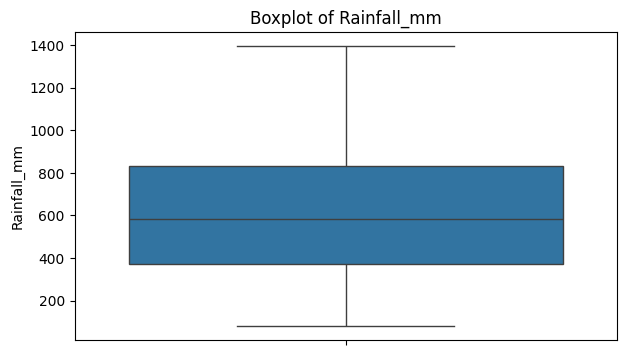

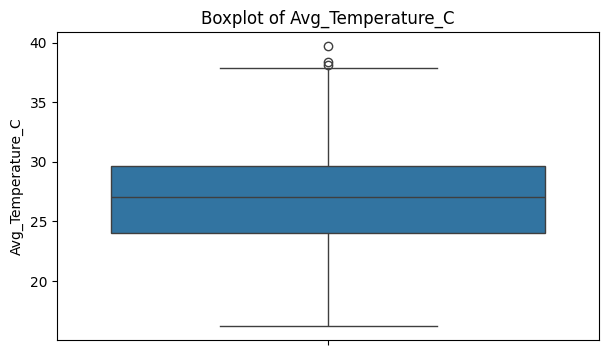

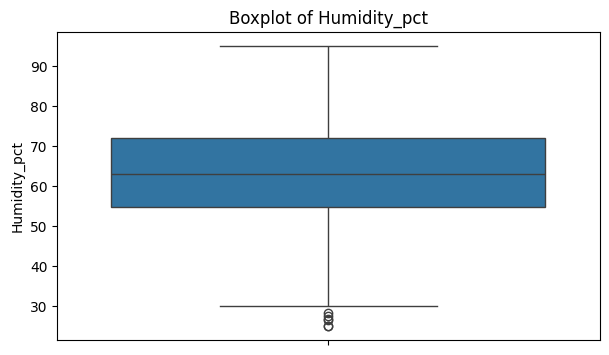

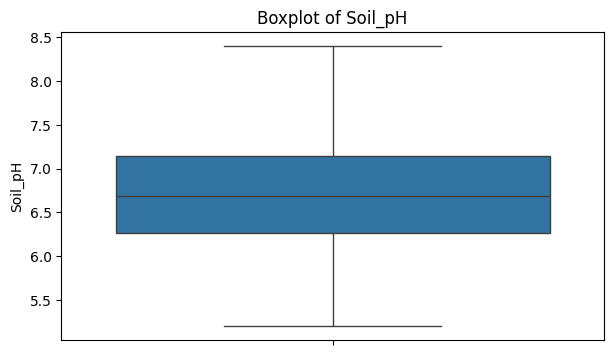

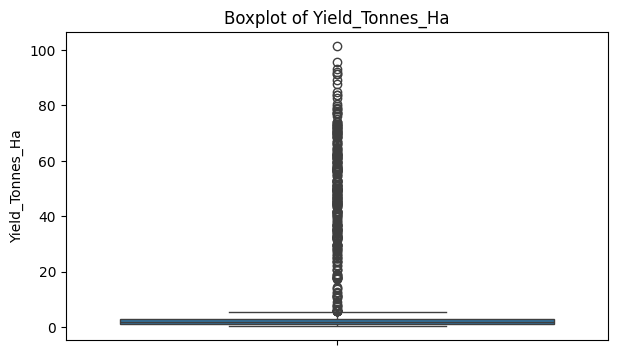

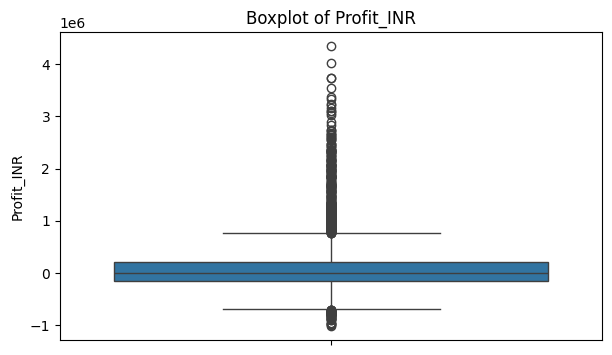

In [42]:
important_numeric_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_pH",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

for col in important_numeric_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(y=col, data=df)
    plt.title("Boxplot of " + col)
    plt.show()

In [43]:
crop_counts = df["Crop"].value_counts()

crop_counts

,count
Crop,
Rice,682
Wheat,612
Maize,547
Cotton,504
Pulses,494
Groundnut,419
Chilli,407
Sugarcane,303


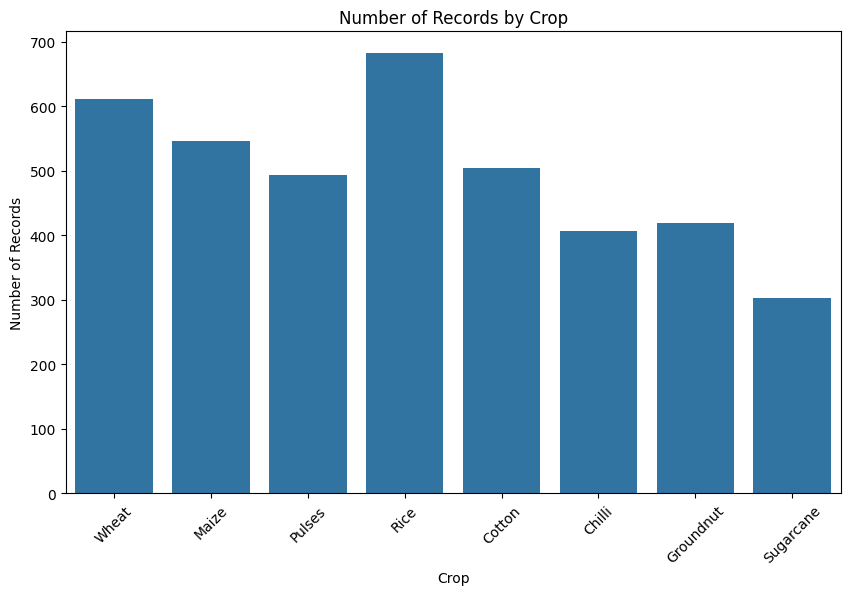

In [44]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Crop")

plt.title("Number of Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

In [45]:
season_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

season_yield.round(2)

,Yield_Tonnes_Ha
Season,
Kharif,5.64
Rabi,5.08
Zaid,4.67


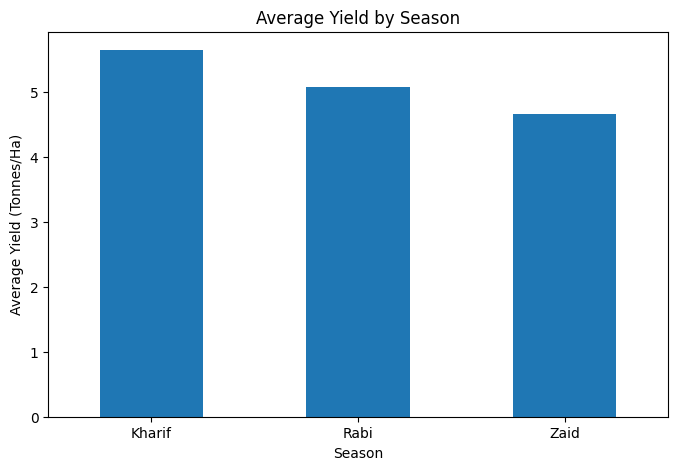

In [46]:
plt.figure(figsize=(8, 5))

season_yield.plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=0)

plt.show()

In [47]:
season_production = (
    df.groupby("Season")["Production_Tonnes"]
    .mean()
    .sort_values(ascending=False)
)

season_production.round(2)

,Production_Tonnes
Season,
Kharif,46.44
Rabi,41.34
Zaid,39.15


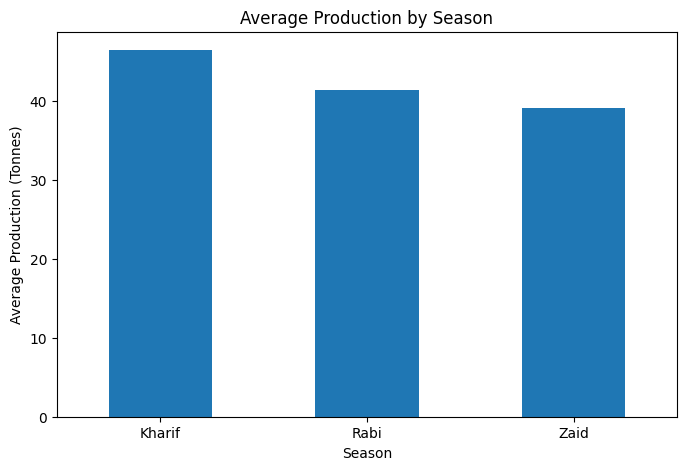

In [48]:
plt.figure(figsize=(8, 5))

season_production.plot(kind="bar")

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")

plt.xticks(rotation=0)

plt.show()

In [49]:
season_revenue = (
    df.groupby("Season")["Revenue_INR"]
    .mean()
    .sort_values(ascending=False)
)

season_revenue.round(2)

,Revenue_INR
Season,
Kharif,711441.28
Rabi,601825.55
Zaid,516662.12


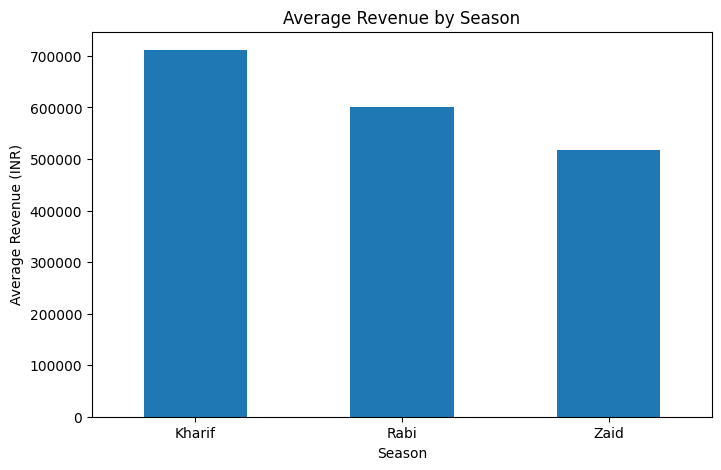

In [50]:
plt.figure(figsize=(8, 5))

season_revenue.plot(kind="bar")

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")

plt.xticks(rotation=0)

plt.show()

In [51]:
season_profit = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

season_profit.round(2)

,Profit_INR
Season,
Kharif,179367.12
Rabi,88197.25
Zaid,-26592.40


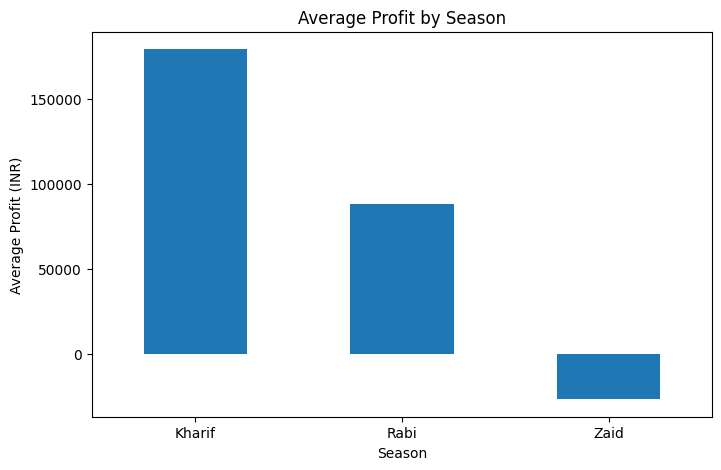

In [52]:
plt.figure(figsize=(8, 5))

season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=0)

plt.show()

In [53]:
#each farm record has a positive profit

df["Profitable"] = df["Profit_INR"] > 0

In [54]:
profit_rate = (
    df.groupby("Season")["Profitable"]
    .mean() * 100
)

profit_rate.round(2)

,Profitable
Season,
Kharif,57.73
Rabi,48.72
Zaid,35.48


In [55]:
profit_rate = (
    df.groupby("Season")["Profitable"]
    .mean() * 100
)

profit_rate.round(2)

,Profitable
Season,
Kharif,57.73
Rabi,48.72
Zaid,35.48


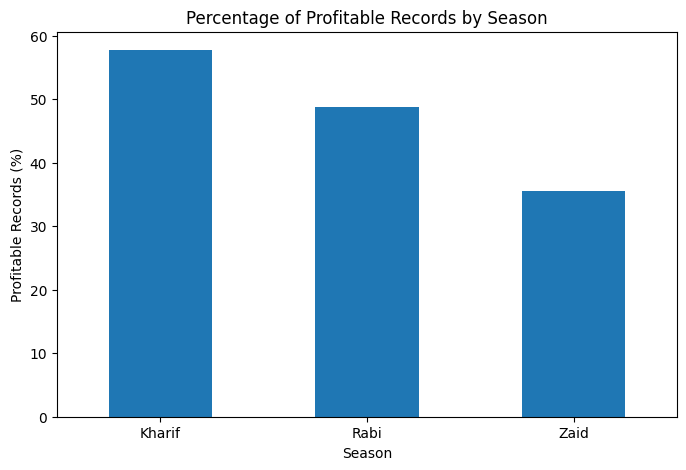

In [56]:
plt.figure(figsize=(8, 5))

profit_rate.plot(kind="bar")

plt.title("Percentage of Profitable Records by Season")
plt.xlabel("Season")
plt.ylabel("Profitable Records (%)")

plt.xticks(rotation=0)

plt.show()

In [57]:
environment_summary = df.groupby("Season")[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day"
]].mean()

environment_summary.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,848.70,28.45,71.84,6.79
Rabi,437.94,23.50,57.92,7.59
Zaid,304.27,31.05,51.99,8.18


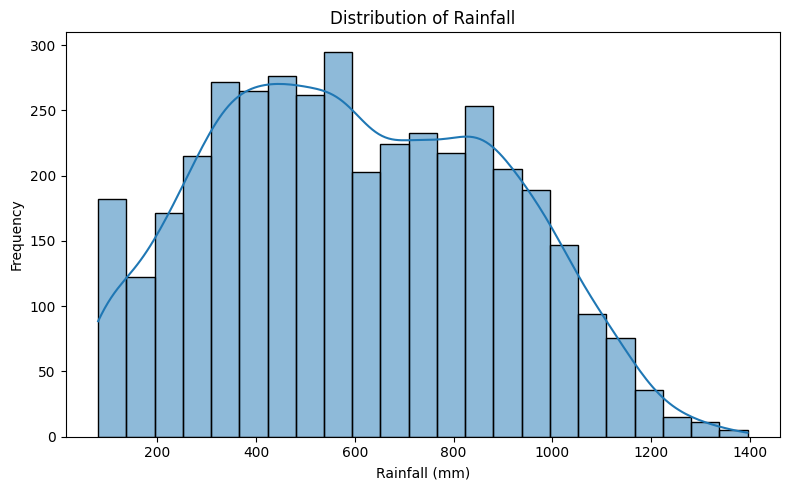

In [91]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


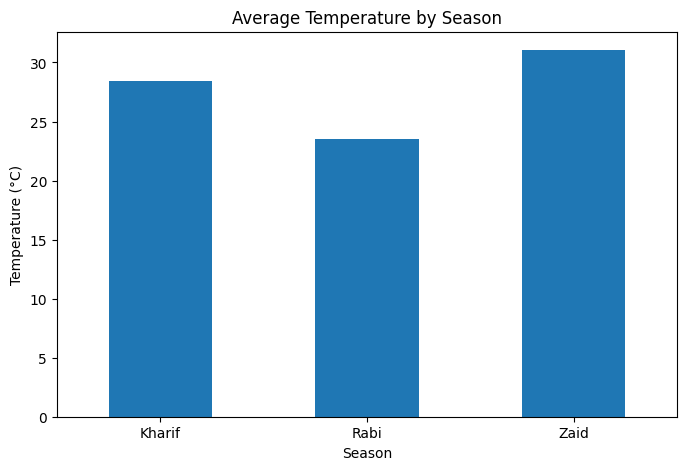

In [59]:
plt.figure(figsize=(8, 5))

df.groupby("Season")["Avg_Temperature_C"].mean().plot(kind="bar")

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=0)

plt.show()

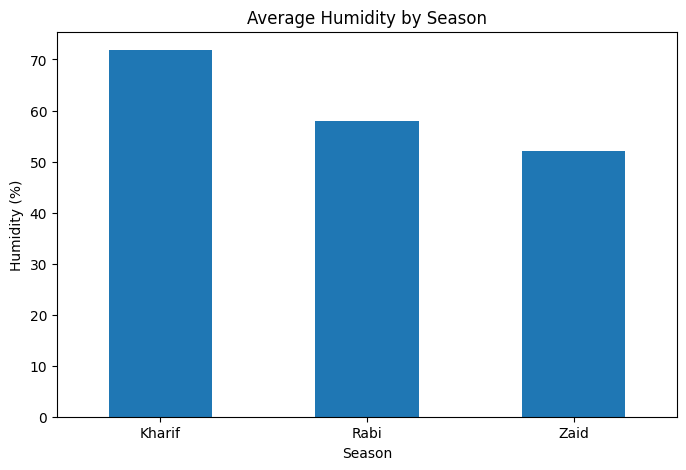

In [61]:
plt.figure(figsize=(8, 5))

df.groupby("Season")["Humidity_pct"].mean().plot(kind="bar")

plt.title("Average Humidity by Season")
plt.xlabel("Season")
plt.ylabel("Humidity (%)")

plt.xticks(rotation=0)

plt.show()

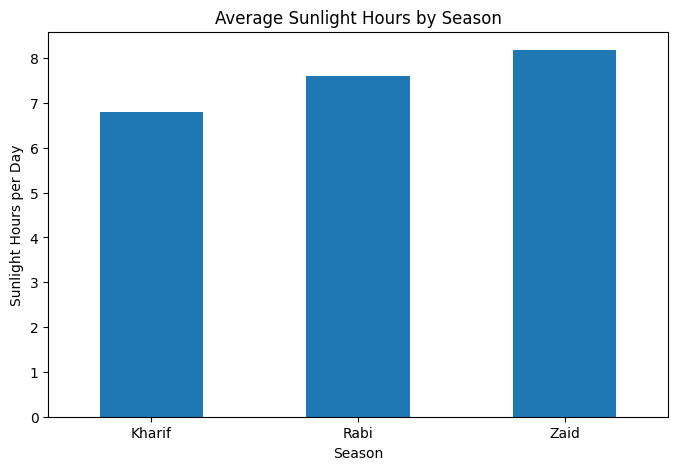

In [62]:
plt.figure(figsize=(8, 5))

df.groupby("Season")["Sunlight_Hours_Day"].mean().plot(kind="bar")

plt.title("Average Sunlight Hours by Season")
plt.xlabel("Season")
plt.ylabel("Sunlight Hours per Day")

plt.xticks(rotation=0)

plt.show()

In [63]:
crop_yield = (
    df.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

crop_yield.round(2)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.94
Maize,2.72
Rice,2.44
Wheat,2.11
Chilli,1.54
Groundnut,1.32
Cotton,1.23
Pulses,0.92


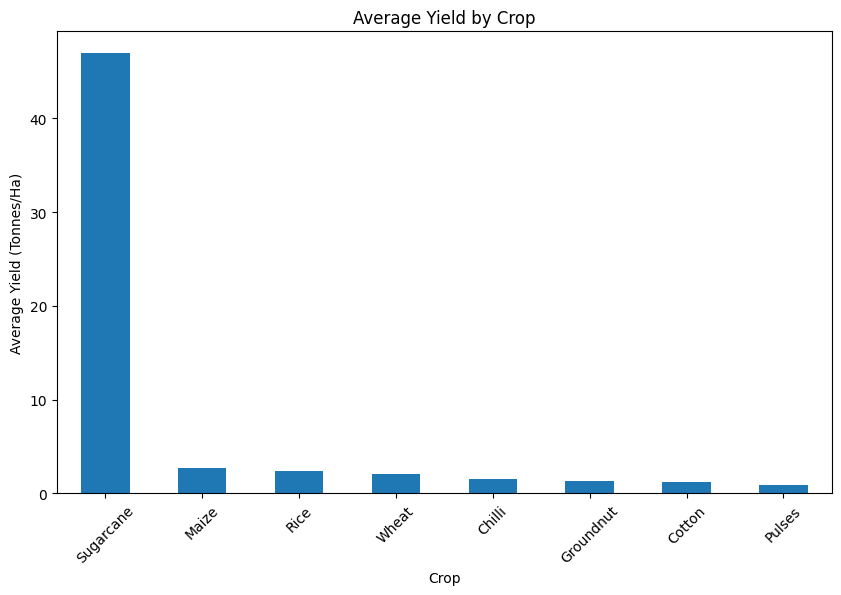

In [64]:
plt.figure(figsize=(10, 6))
crop_yield.plot(kind="bar")
plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()


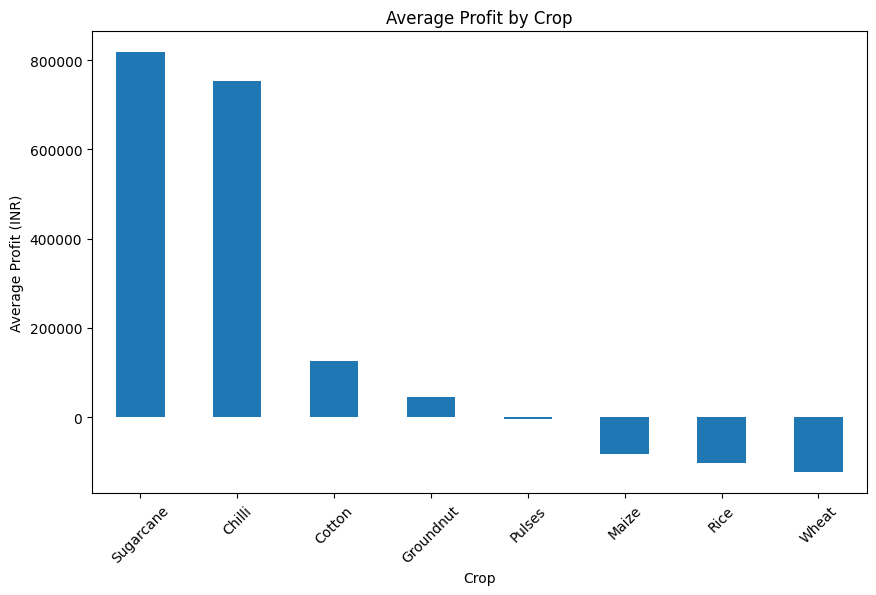

In [65]:
crop_profit = (
 df.groupby("Crop")["Profit_INR"]
 .mean()
 .sort_values(ascending=False)
)
crop_profit.round(2)
plt.figure(figsize=(10, 6))
crop_profit.plot(kind="bar")
plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.show()
#cropwise profit

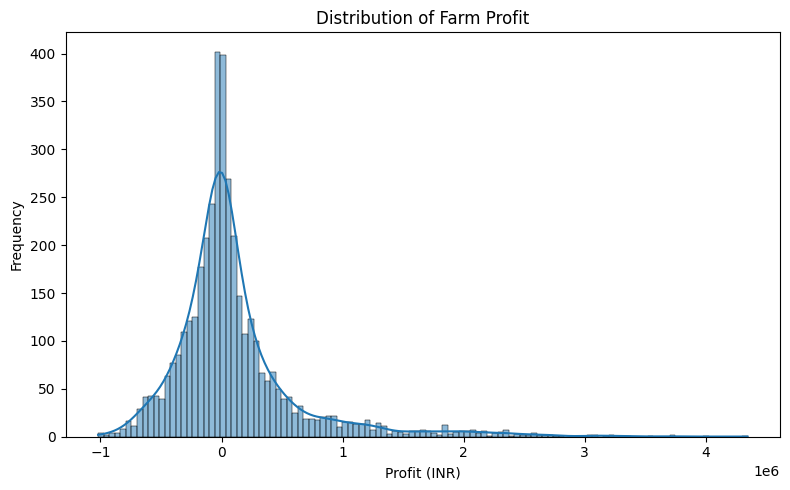

In [89]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


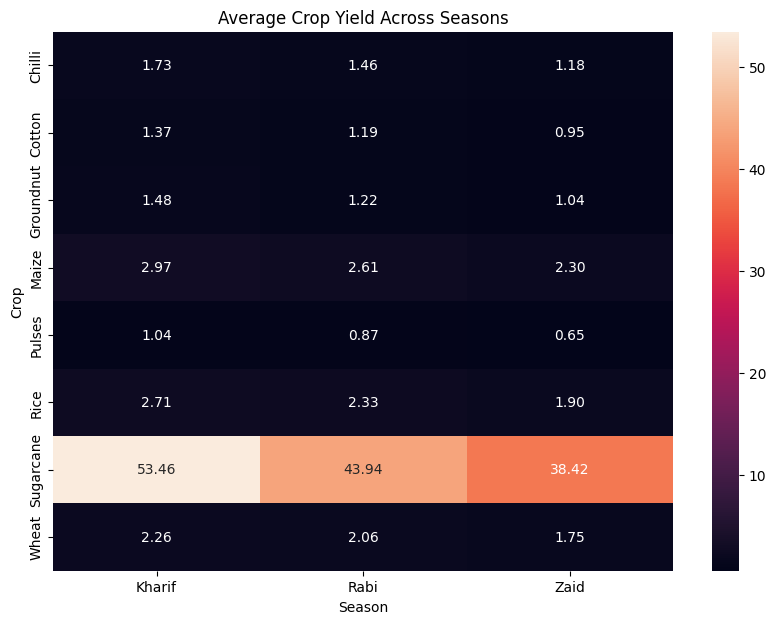

In [66]:
season_crop_yield = pd.pivot_table(
 df,
 values="Yield_Tonnes_Ha",
 index="Crop",
 columns="Season",
 aggfunc="mean"
)
season_crop_yield.round(2)
plt.figure(figsize=(10, 7))
sns.heatmap(season_crop_yield, annot=True, fmt=".2f")
plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

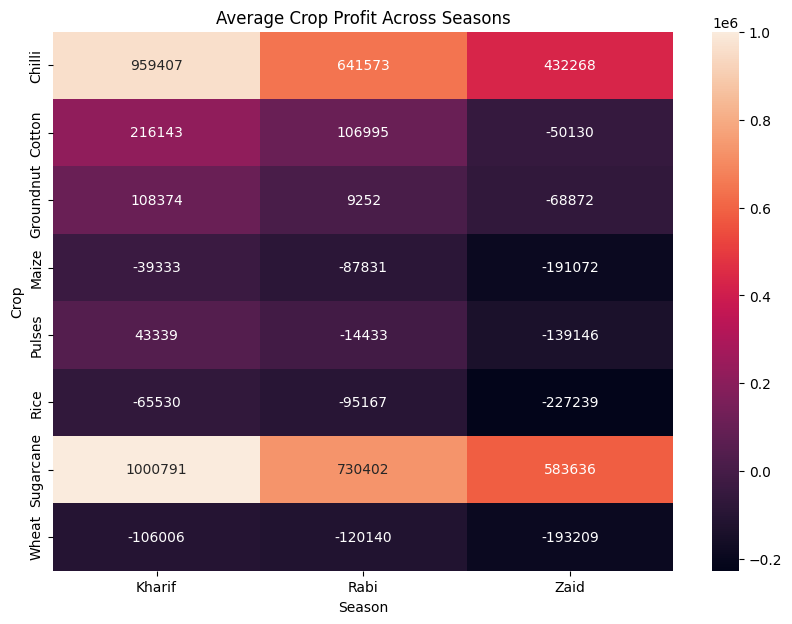

In [67]:
season_crop_profit = pd.pivot_table(
 df,
 values="Profit_INR",
 index="Crop",
 columns="Season",
 aggfunc="mean"
)
season_crop_profit.round(2)
plt.figure(figsize=(10, 7))
sns.heatmap(season_crop_profit, annot=True, fmt=".0f")
plt.title("Average Crop Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()


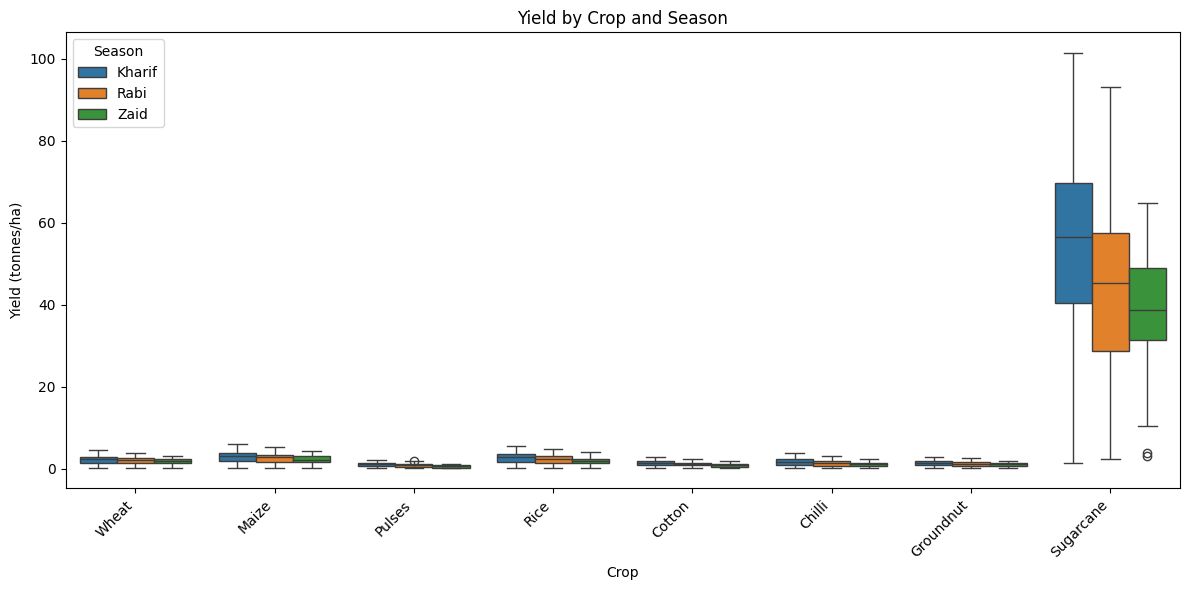

In [93]:
# Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


In [68]:
crop_season_profit = (
 df.groupby(["Season", "Crop"])["Profit_INR"]
 .mean()
 .sort_values(ascending=False)
)
crop_season_profit.head(10)
crop_season_profit.tail(10)

Season  Crop     
Kharif  Rice         -65529.829582
Zaid    Groundnut    -68872.500000
Rabi    Maize        -87830.878261
        Rice         -95167.371747
Kharif  Wheat       -106005.807560
Rabi    Wheat       -120140.457627
Zaid    Pulses      -139145.540984
        Maize       -191072.204819
        Wheat       -193208.952941
        Rice        -227239.343137
Name: Profit_INR, dtype: float64

In [69]:
irrigation_summary = df.groupby("Irrigation_Method")[[
 "Yield_Tonnes_Ha",
 "Water_Used_m3",
 "Water_Efficiency_t_per_1000m3",
 "Profit_INR"
]].mean()
irrigation_summary.round(2)


,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.62,5901.44,6.23,219002.41
Flood,4.90,8028.81,3.46,72918.99
Rainfed,4.61,3551.55,7.57,79509.51
Sprinkler,5.19,6210.70,4.69,93844.83


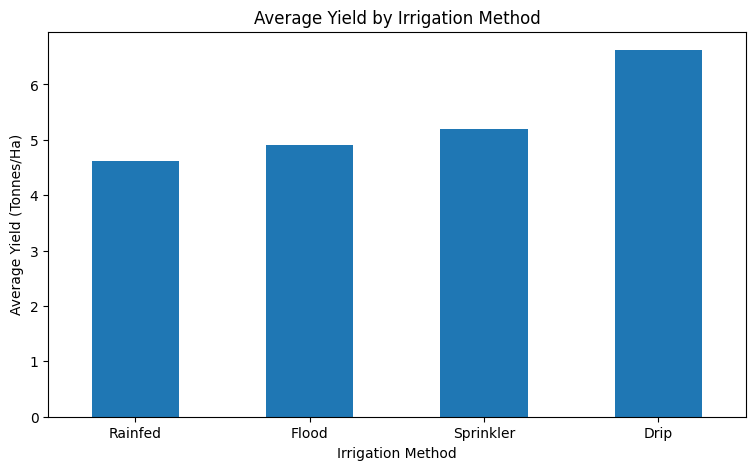

In [70]:
plt.figure(figsize=(9, 5))
df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values().plot(
 kind="bar"
)
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()

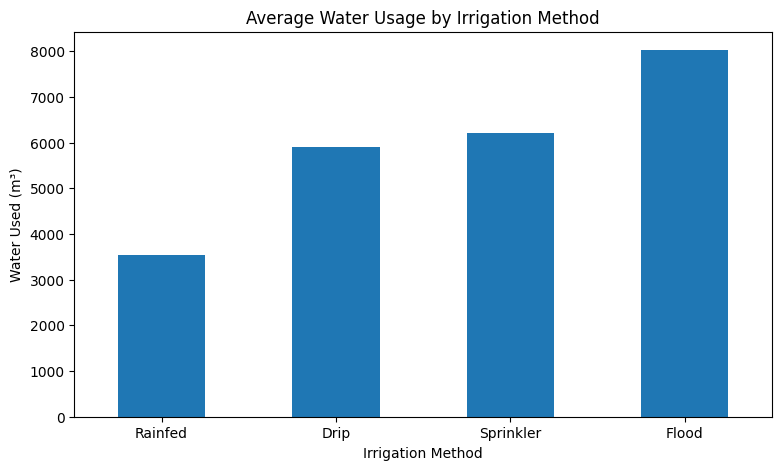

In [71]:
plt.figure(figsize=(9, 5))
df.groupby("Irrigation_Method")["Water_Used_m3"].mean().sort_values().plot(
 kind="bar"
)
plt.title("Average Water Usage by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=0)
plt.show()


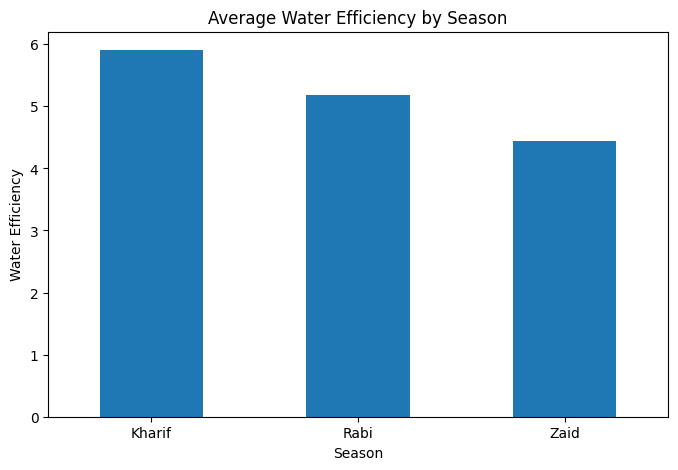

In [72]:
water_efficiency = (
 df.groupby("Season")["Water_Efficiency_t_per_1000m3"]
 .mean()
)
water_efficiency.round(2)
plt.figure(figsize=(8, 5))
water_efficiency.plot(kind="bar")
plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")
plt.xticks(rotation=0)
plt.show()

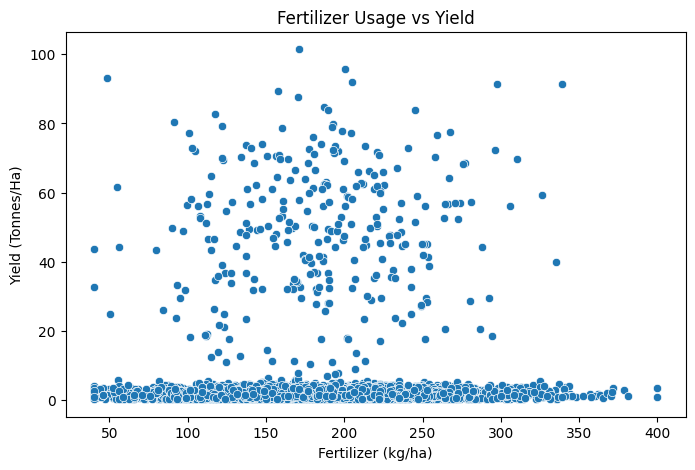

In [73]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
 x="Fertilizer_kg_ha",
 y="Yield_Tonnes_Ha",
 data=df
)
plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

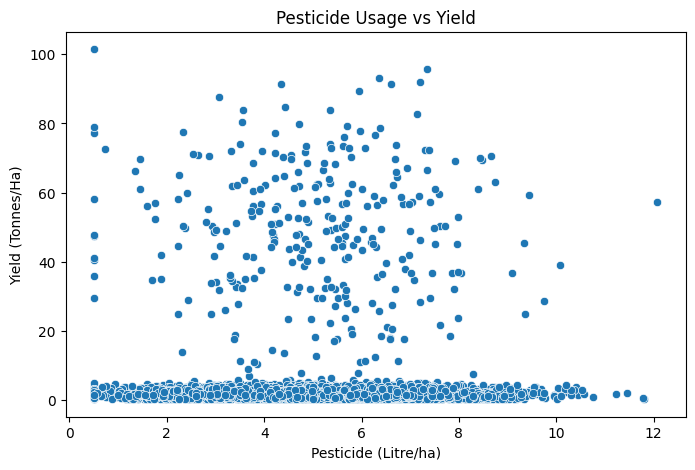

In [74]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
 x="Pesticide_Litre_ha",
 y="Yield_Tonnes_Ha",
 data=df
)
plt.title("Pesticide Usage vs Yield")
plt.xlabel("Pesticide (Litre/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

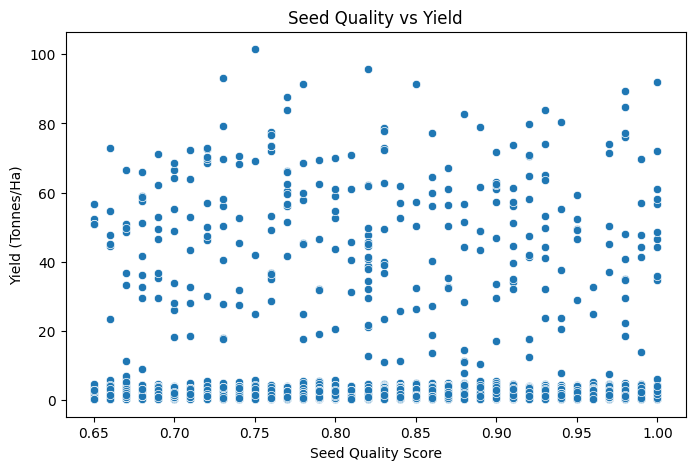

In [75]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
 x="Seed_Quality_Score",
 y="Yield_Tonnes_Ha",
 data=df
)
plt.title("Seed Quality vs Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()


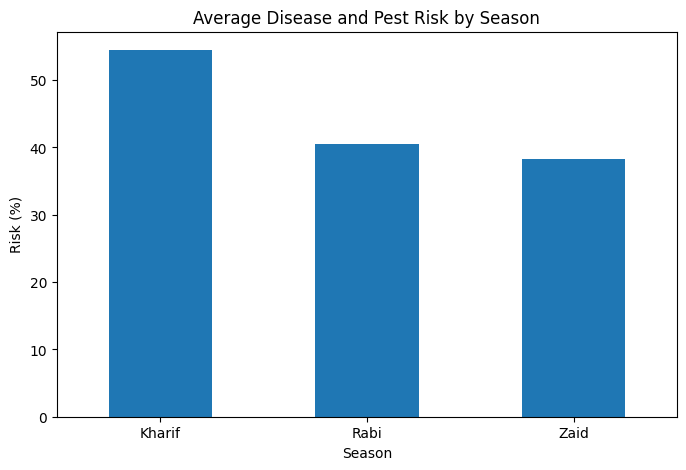

In [77]:
risk_by_season = (
 df.groupby("Season")["Disease_Pest_Risk_pct"]
 .mean()
)
risk_by_season.round(2)
plt.figure(figsize=(8, 5))
risk_by_season.plot(kind="bar")
plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.show()

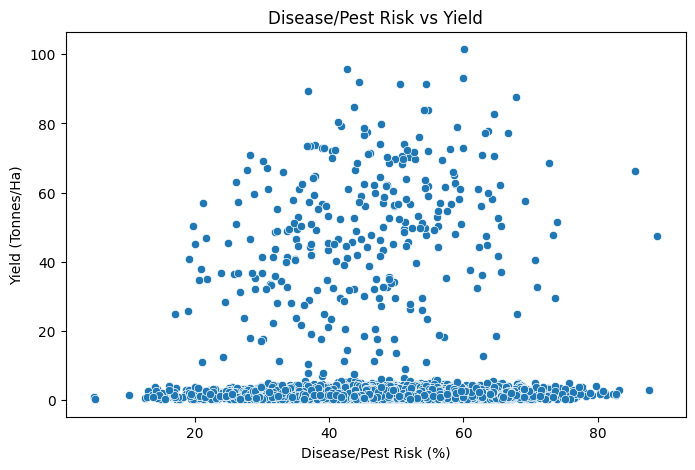

In [78]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
 x="Disease_Pest_Risk_pct",
 y="Yield_Tonnes_Ha",
 data=df
)
plt.title("Disease/Pest Risk vs Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()


In [79]:
state_summary = df.groupby("State").agg({
 "Yield_Tonnes_Ha": "mean",
 "Profit_INR": "mean",
 "Water_Used_m3": "mean"
})
state_summary.round(2)

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3
State,,,
Andhra Pradesh,4.65,69497.23,6062.46
Gujarat,5.70,120050.96,6120.73
Karnataka,5.73,118495.57,6418.22
Madhya Pradesh,5.03,89479.77,5612.88
Maharashtra,5.03,136874.14,5977.12
Punjab,6.12,136025.64,6565.92
Tamil Nadu,4.90,119117.82,5800.76
Telangana,5.08,108282.06,5774.68


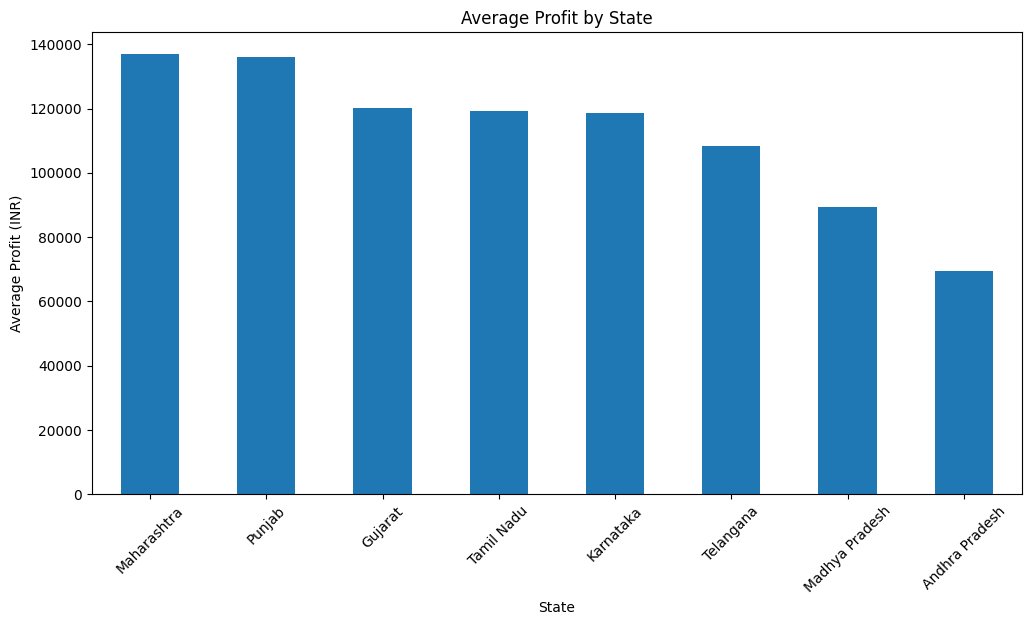

In [80]:
state_profit = (
 df.groupby("State")["Profit_INR"]
 .mean()
 .sort_values(ascending=False)
)
state_profit.round(2)
plt.figure(figsize=(12, 6))
state_profit.plot(kind="bar")
plt.title("Average Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.show()


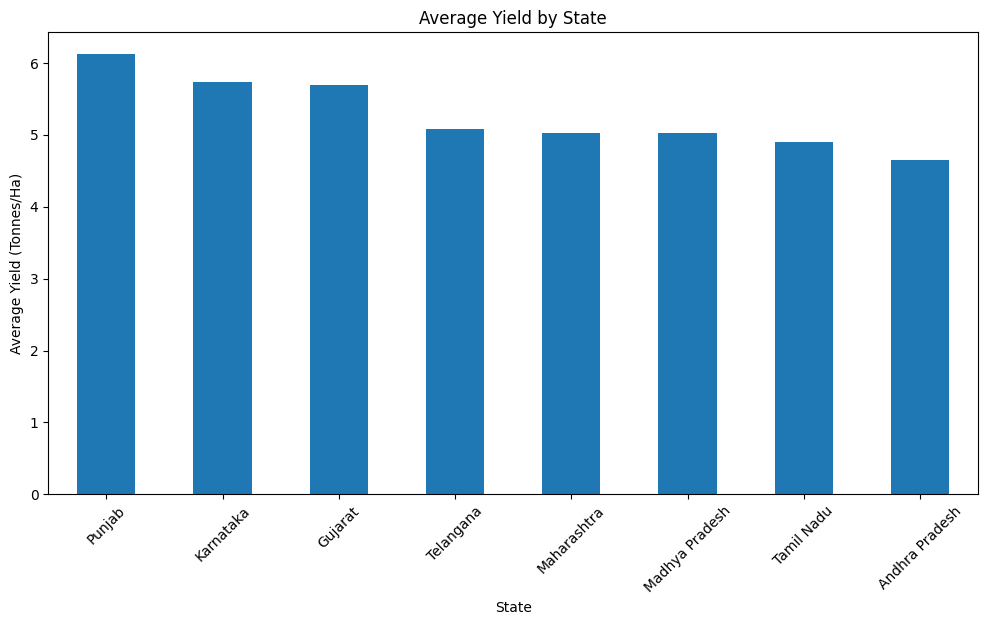

In [81]:
state_yield = (
 df.groupby("State")["Yield_Tonnes_Ha"]
 .mean()
 .sort_values(ascending=False)
)
state_yield.round(2)
plt.figure(figsize=(12, 6))
state_yield.plot(kind="bar")
plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()


In [82]:
season_statistics = df.groupby("Season")["Yield_Tonnes_Ha"].agg([
 "mean",
 "median",
 "std",
 "min",
 "max"
])
season_statistics.round(2)

,mean,median,std,min,max
Season,,,,,
Kharif,5.64,1.95,14.42,0.3,101.44
Rabi,5.08,1.66,12.83,0.3,93.13
Zaid,4.67,1.45,11.32,0.3,64.76


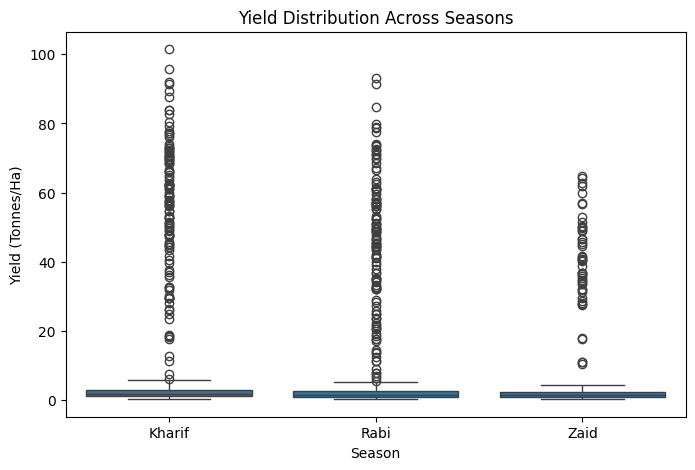

In [83]:
plt.figure(figsize=(8, 5))
sns.boxplot(
 x="Season",
 y="Yield_Tonnes_Ha",
 data=df
)
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()


In [84]:
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()
correlation.round(2)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,-0.00,0.00,0.01,0.00,0.02,-0.00,-0.00,...,0.01,0.03,0.20,-0.02,0.96,0.54,0.11,0.58,0.03,0.02
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,...,-0.02,0.03,0.03,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,...,-0.03,0.01,0.01,0.00,0.04,0.02,0.01,0.02,0.01,0.24
Humidity_pct,-0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,...,-0.05,0.01,0.00,0.00,0.00,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,...,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.06,-0.00,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.00,0.02,-0.02,...,-0.00,-0.02,-0.01,0.02,0.00,-0.01,-0.01,-0.03,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,...,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.37
Nitrogen_kg_ha,0.02,0.01,0.02,0.00,0.01,0.00,0.01,1.00,0.01,0.01,...,0.02,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.06,-0.01
Phosphorus_kg_ha,-0.00,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,...,-0.01,0.05,0.04,-0.01,-0.01,0.04,0.05,0.00,0.06,0.03
Potassium_kg_ha,-0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,...,0.01,0.00,0.00,0.01,0.00,0.03,0.03,-0.00,0.01,0.01


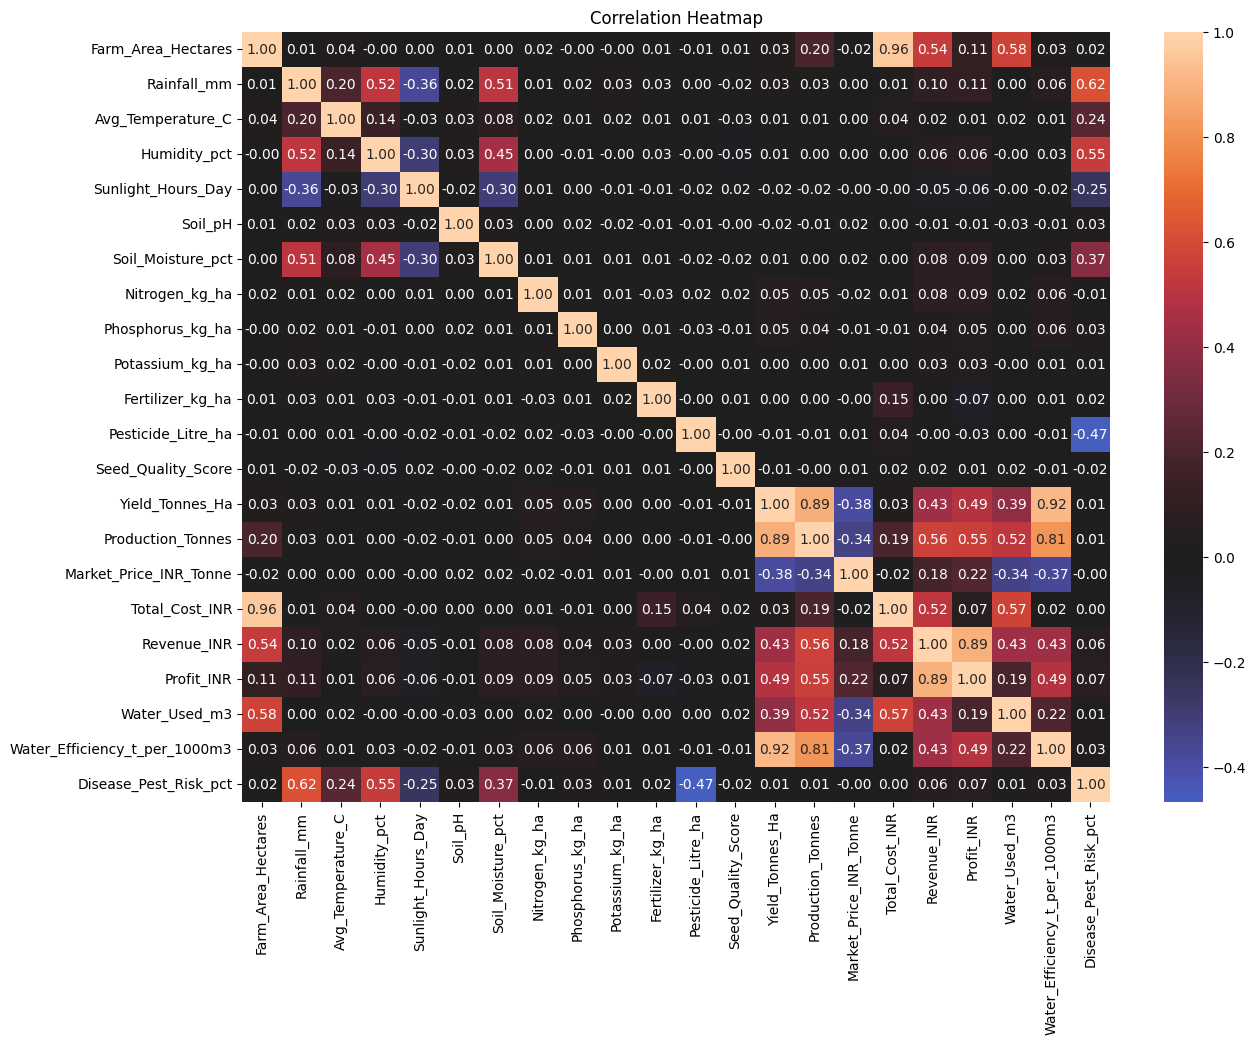

In [85]:
plt.figure(figsize=(14, 10))
sns.heatmap(
 correlation,
 annot=True,
 fmt=".2f",
 center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [86]:
yield_correlation = (
 correlation["Yield_Tonnes_Ha"]
 .sort_values(ascending=False)
)
yield_correlation.round(2)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.92
Production_Tonnes,0.89
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Total_Cost_INR,0.03
Rainfall_mm,0.03


In [87]:
final_summary = df.groupby("Season").agg({
 "Yield_Tonnes_Ha": "mean",
 "Production_Tonnes": "mean",
 "Revenue_INR": "mean",
 "Profit_INR": "mean",
 "Water_Used_m3": "mean",
 "Water_Efficiency_t_per_1000m3": "mean",
 "Disease_Pest_Risk_pct": "mean"
})
final_summary.round(2)


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.64,46.44,711441.28,179367.12,6094.05,5.91,54.47
Rabi,5.08,41.34,601825.55,88197.25,5837.24,5.18,40.52
Zaid,4.67,39.15,516662.12,-26592.40,6423.08,4.44,38.22


In [88]:
best_yield_season = season_yield.idxmax()
best_profit_season = season_profit.idxmax()
best_yield_crop = crop_yield.idxmax()
best_profit_crop = crop_profit.idxmax()
best_profit_combination = crop_season_profit.idxmax()
print("Season with highest average yield:", best_yield_season)
print("Season with highest average profit:", best_profit_season)
print("Crop with highest average yield:", best_yield_crop)
print("Crop with highest average profit:", best_profit_crop)
print("Highest average profit crop-season combination:",
 best_profit_combination)


Season with highest average yield: Kharif
Season with highest average profit: Kharif
Crop with highest average yield: Sugarcane
Crop with highest average profit: Sugarcane
Highest average profit crop-season combination: ('Kharif', 'Sugarcane')


##
 Limitations

- The analysis is based only on the variables available in the dataset.
- The dataset may not represent every agricultural region or farming condition.
- The analysis is based on the available observations and does not cover
  every possible agricultural factor.
- Correlation shows relationships between variables but does not prove
  cause and effect.
- More years of data would help make seasonal comparisons stronger.
- External factors such as government policies, market changes and unexpected
  weather events are not fully covered in the dataset.